# NB3 — Position-Specific Regression Models
**Motivation:** NB1 and NB2 use a single global model that treats all positions identically.
A goalkeeper earns points from clean sheets and saves; a forward scores from goals.
Training separate models per position allows each to learn position-specific scoring patterns.

**Configuration:** Same as NB2 (featured data + combined weighting + StandardScaler)
but trained independently for GK, DEF, MID, FWD.

**Same 85/15 walk-forward split:** GW1--14 of 2025/26 + all prior seasons → train | GW15--29 → test

---
## ⚠️ Two Sessions Required
- **Session 1:** PyCaret (one model per position)
- **Session 2:** AutoKeras (restart runtime)

Cells 1--6 (Setup through Normalization) must be re-run in Session 2.

## 1. Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE = '/content/drive/MyDrive/fpl_thesis'
MODEL_DIR = f'{BASE}/models/nb3_position_models'
DATA_DIR  = f'{BASE}/data/processed/nb3_position_models'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR,  exist_ok=True)
print('Drive mounted and folders ready')

Mounted at /content/drive
Drive mounted and folders ready


## 2. Load Featured Dataset

In [2]:
import pandas as pd
import numpy as np

DATA_PATH = f'{BASE}/data/processed/featured_training_set.csv'
df = pd.read_csv(DATA_PATH)
df = df.sort_values(['element', 'season', 'GW']).reset_index(drop=True)
print(f'Loaded: {df.shape}')
print(f'Positions: {df["position"].value_counts().to_dict()}')
print(df.head(3))

Loaded: (79277, 34)
Positions: {'MID': 34916, 'DEF': 25972, 'FWD': 9249, 'GK': 8818, 'AM': 322}
              name     team position  element  season  GW  total_points  \
0  Folarin Balogun  Arsenal      FWD        1    2324   1             0   
1  Folarin Balogun  Arsenal      FWD        1    2324   2             0   
2  Folarin Balogun  Arsenal      FWD        1    2324   3             0   

   value  price_change  pts_per_million  ...  played_60_plus  blanked  \
0    4.5           0.0              0.0  ...               0        1   
1    4.5           0.0              0.0  ...               0        1   
2    4.5           0.0              0.0  ...               0        1   

   red_card_flag  opp_avg_goals_scored  opp_avg_goals_conceded  \
0              0                   NaN                     NaN   
1              0              0.060606                0.333333   
2              0              0.045009                0.166667   

   team_rolling_pts_3  team_rolling_goals_3  

## 3. Define Features and Target

In [3]:
META_COLS = ['name', 'team', 'position', 'element', 'season', 'GW', 'total_points']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# Target: next GW points
df['target'] = df.groupby(['element', 'season'])['total_points'].shift(-1)
df = df.dropna(subset=['target']).reset_index(drop=True)
print(f'After target shift: {df.shape}')

# Filter non-playing rows
df_playing = df[df['rolling_mins_3'] > 0].copy()
print(f'After filtering non-players: {df_playing.shape}')
print(f'Position distribution after filter:')
print(df_playing['position'].value_counts())

Feature columns (27): ['value', 'price_change', 'pts_per_million', 'position_enc', 'rolling_pts_3', 'rolling_pts_5', 'rolling_pts_std_3', 'rolling_pts_std_5', 'rolling_goals_3', 'rolling_assists_3', 'rolling_mins_3', 'rolling_gi_3', 'form_trend', 'pct_matches_played', 'games_played', 'was_home', 'team_match_result', 'played_60_plus', 'blanked', 'red_card_flag', 'opp_avg_goals_scored', 'opp_avg_goals_conceded', 'team_rolling_pts_3', 'team_rolling_goals_3', 'gi_rate', 'rolling_yellows_3', 'transfers_per_selected']
After target shift: (76834, 35)
After filtering non-players: (38297, 35)
Position distribution after filter:
position
MID    18159
DEF    13191
FWD     4458
GK      2487
AM         2
Name: count, dtype: int64


## 4. Walk-Forward Split (85/15)

In [4]:
train_all = df_playing[~((df_playing['season'] == 2526) & (df_playing['GW'] >= 15))].copy()
test_all  = df_playing[  (df_playing['season'] == 2526) & (df_playing['GW'] >= 15)].copy()

print(f'Train: {len(train_all)} rows ({len(train_all)/len(df_playing)*100:.1f}%)')
print(f'Test:  {len(test_all)} rows ({len(test_all)/len(df_playing)*100:.1f}%)')
print()
print('Train position counts:')
print(train_all['position'].value_counts())
print('\nTest position counts:')
print(test_all['position'].value_counts())

Train: 33031 rows (86.2%)
Test:  5266 rows (13.8%)

Train position counts:
position
MID    15735
DEF    11300
FWD     3824
GK      2170
AM         2
Name: count, dtype: int64

Test position counts:
position
MID    2424
DEF    1891
FWD     634
GK      317
Name: count, dtype: int64


## 5. Combined Sample Weighting

In [5]:
def get_combined_weight(row):
    season_w = {2324: 0.5, 2425: 0.75, 2526: 1.0}.get(int(row['season']), 1.0)
    if row['rolling_mins_3'] < 30:
        return season_w * 0.3
    elif row['target'] <= 1:
        return season_w * 0.5
    elif row['target'] <= 5:
        return season_w * 1.0
    elif row['target'] <= 9:
        return season_w * 2.0
    else:
        return season_w * 3.0

train_all['weight'] = train_all.apply(get_combined_weight, axis=1)
print('Combined weight distribution:')
print(pd.Series(train_all['weight'].values).describe())

Combined weight distribution:
count    33031.000000
mean         0.522480
std          0.453484
min          0.150000
25%          0.250000
50%          0.375000
75%          0.750000
max          3.000000
dtype: float64


## 6. Imputation and Normalization (per position)
Each position gets its own scaler fitted on its own training data.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pickle

POSITIONS = ['GK', 'DEF', 'MID', 'FWD']
pos_data = {}

for pos in POSITIONS:
    train_pos = train_all[train_all['position'] == pos].copy()
    test_pos  = test_all[test_all['position']   == pos].copy()

    X_train = train_pos[FEATURE_COLS].values.astype(np.float32)
    y_train = train_pos['target'].values.astype(np.float32)
    w_train = train_pos['weight'].values
    X_test  = test_pos[FEATURE_COLS].values.astype(np.float32)
    y_test  = test_pos['target'].values.astype(np.float32)

    imputer = SimpleImputer(strategy='mean')
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp  = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_test_scaled  = scaler.transform(X_test_imp)

    # Save scaler and imputer
    with open(f'{MODEL_DIR}/scaler_{pos}.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    with open(f'{MODEL_DIR}/imputer_{pos}.pkl', 'wb') as f:
        pickle.dump(imputer, f)

    pos_data[pos] = {
        'train_meta': train_pos[['name','team','position','element','season','GW']],
        'test_meta':  test_pos[['name','team','position','element','season','GW']],
        'X_train': X_train_scaled, 'y_train': y_train, 'w_train': w_train,
        'X_test':  X_test_scaled,  'y_test':  y_test,
        'X_train_imp': X_train_imp, 'X_test_imp': X_test_imp
    }
    print(f'{pos}: train={len(X_train_scaled)}, test={len(X_test_scaled)}')

print('\nAll scalers and imputers saved.')

GK: train=2170, test=317
DEF: train=11300, test=1891
MID: train=15735, test=2424
FWD: train=3824, test=634

All scalers and imputers saved.


---
# SESSION 1 — PyCaret (one model per position)
Run fully, save all models, then restart runtime for Session 2.

## 7. Install PyCaret

In [ ]:
!pip install scikit-learn==1.4.2 pycaret==3.3.2 -q
print('PyCaret installed')

PyCaret installed


## 8. Train PyCaret Model per Position

In [ ]:
import pandas as pd
import numpy as np
from pycaret.regression import *
from sklearn.metrics import mean_absolute_error, r2_score
import pickle, json

POSITIONS = ['GK', 'DEF', 'MID', 'FWD']
pycaret_results = {}

for pos in POSITIONS:
    print(f'\n{"="*40}')
    print(f'Training PyCaret model for {pos}')
    print(f'{"="*40}')

    d = pos_data[pos]

    # Build scaled DataFrame
    train_pc = pd.DataFrame(d['X_train'], columns=FEATURE_COLS)
    train_pc['target'] = d['y_train']
    test_pc  = pd.DataFrame(d['X_test'],  columns=FEATURE_COLS)

    s = setup(
        data            = train_pc,
        target          = 'target',
        session_id      = 42,
        normalize       = False,
        imputation_type = None,
        data_split_shuffle = False,
        fold            = 5,
        verbose         = False,
    )

    best_models = compare_models(
        sort    = 'MAE',
        n_select= 1,
        exclude = ['ransac', 'rf', 'et', 'ada', 'gbr'],
        verbose = False
    )

    tuned = tune_model(best_models, optimize='MAE', n_iter=20, verbose=False)

    preds = predict_model(tuned, data=test_pc)
    pred_values = np.clip(preds['prediction_label'].values, 0, None)

    mae = mean_absolute_error(d['y_test'], pred_values)
    r2  = r2_score(d['y_test'], pred_values)
    naive_mae = mean_absolute_error(d['y_test'], np.full(len(d['y_test']), d['y_train'].mean()))

    print(f'{pos} — Best: {type(best_models).__name__}')
    print(f'{pos} — MAE: {mae:.4f} | R²: {r2:.4f} | Naive: {naive_mae:.4f} | Impr: {((naive_mae-mae)/naive_mae)*100:.1f}%')

    # Save model
    save_model(tuned, f'{MODEL_DIR}/pycaret_{pos}')

    # Save predictions
    pred_df = d['test_meta'].copy().reset_index(drop=True)
    pred_df['y_true'] = d['y_test']
    pred_df['pred']   = pred_values
    pred_df.to_csv(f'{DATA_DIR}/preds_{pos}.csv', index=False)

    pycaret_results[pos] = {
        'model': type(best_models).__name__,
        'mae': float(mae), 'r2': float(r2), 'naive_mae': float(naive_mae)
    }

with open(f'{DATA_DIR}/pycaret_results.json', 'w') as f:
    json.dump(pycaret_results, f)

print('\nAll PyCaret models saved.')
print('→ Restart runtime for AutoKeras session')


Training PyCaret model for GK


GK — Best: HuberRegressor
GK — MAE: 1.8021 | R²: 0.0556 | Naive: 2.0721 | Impr: 13.0%
Transformation Pipeline and Model Successfully Saved

Training PyCaret model for DEF


DEF — Best: HuberRegressor
DEF — MAE: 1.7790 | R²: -0.0117 | Naive: 2.0872 | Impr: 14.8%
Transformation Pipeline and Model Successfully Saved

Training PyCaret model for MID


MID — Best: HuberRegressor
MID — MAE: 1.5680 | R²: 0.1130 | Naive: 1.9546 | Impr: 19.8%
Transformation Pipeline and Model Successfully Saved

Training PyCaret model for FWD


FWD — Best: HuberRegressor
FWD — MAE: 1.6869 | R²: 0.0513 | Naive: 2.1496 | Impr: 21.5%
Transformation Pipeline and Model Successfully Saved

All PyCaret models saved.
→ Restart runtime for AutoKeras session


## 9. PyCaret Summary

In [ ]:
import json
with open(f'{DATA_DIR}/pycaret_results.json') as f:
    res = json.load(f)

print(f'{"Position":<8} {"Model":<25} {"MAE":>8} {"R²":>8} {"Naive":>8} {"Impr":>8}')
print('-' * 70)
for pos, r in res.items():
    impr = ((r['naive_mae'] - r['mae']) / r['naive_mae']) * 100
    print(f'{pos:<8} {r["model"]:<25} {r["mae"]:>8.4f} {r["r2"]:>8.4f} {r["naive_mae"]:>8.4f} {impr:>7.1f}%')
print('\nAll models saved → Restart runtime for AutoKeras')

Position Model                          MAE       R²    Naive     Impr
----------------------------------------------------------------------
GK       HuberRegressor              1.8021   0.0556   2.0721    13.0%
DEF      HuberRegressor              1.7790  -0.0117   2.0872    14.8%
MID      HuberRegressor              1.5680   0.1130   1.9546    19.8%
FWD      HuberRegressor              1.6869   0.0513   2.1496    21.5%

All models saved → Restart runtime for AutoKeras


---
# SESSION 2 — AutoKeras (one model per position)
⚠️ Restart runtime before this section.
Re-run cells 1--6 before continuing.

## 10. Install AutoKeras

In [8]:
!pip install autokeras==3.0.0 tensorflow==2.18.0 -q
print('AutoKeras installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 18.4 MB/s eta 0:00:00
AutoKeras installed


## 11. AutoKeras per Position

In [ ]:
import autokeras as ak
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
import json

print(f'TF: {tf.__version__} | AK: {ak.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

POSITIONS = ['GK', 'DEF', 'MID', 'FWD']
ak_results = {}

for pos in POSITIONS:
    print(f'\n{"="*40}')
    print(f'AutoKeras for {pos}')
    print(f'{"="*40}')

    d = pos_data[pos]

    ak_model = ak.StructuredDataRegressor(
        max_trials   = 10,
        overwrite    = True,
        seed         = 42,
        directory    = f'{MODEL_DIR}/ak_trials_{pos}',
        project_name = f'nb3_{pos}'
    )

    ak_model.fit(
        d['X_train_imp'],
        d['y_train'],
        epochs           = 35,
        validation_split = 0.1,
        verbose          = 0
    )

    ak_preds = np.clip(ak_model.predict(d['X_test_imp']).flatten(), 0, None)
    mae = mean_absolute_error(d['y_test'], ak_preds)
    r2  = r2_score(d['y_test'], ak_preds)

    print(f'{pos} — AutoKeras MAE: {mae:.4f} | R²: {r2:.4f}')

    best_ak = ak_model.export_model()
    best_ak.save(f'{MODEL_DIR}/autokeras_{pos}.keras')

    ak_results[pos] = {'mae': float(mae), 'r2': float(r2)}

with open(f"{DATA_DIR}/autokeras_results.json", 'w') as f:
    json.dump(ak_results, f)

print('\nAll AutoKeras models saved.')

TF: 2.18.0 | AK: 3.0.0
GPU: True

AutoKeras for GK


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1953, 27))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 27))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 27))
  warnings.warn(msg)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
GK — AutoKeras MAE: 2.0276 | R²: 0.0939


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



AutoKeras for DEF


...

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(3442, 27))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 27))
  warnings.warn(msg)


 1/20 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 27))
  warnings.warn(msg)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
FWD — AutoKeras MAE: 2.0556 | R²: 0.1380

All AutoKeras models saved.


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 12. Model Comparison and Winner per Position

In [11]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

with open(f'{DATA_DIR}/pycaret_results.json') as f:
    pc_res = json.load(f)
with open(f'{DATA_DIR}/autokeras_results.json') as f:
    ak_res = json.load(f)

def mae_at_k(df, pred_col, k=15):
    errors = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_k = gw_df.nlargest(k, 'y_true')
        errors.append(mean_absolute_error(top_k['y_true'], top_k[pred_col]))
    return np.mean(errors)

def precision_at_k(df, pred_col, k=15):
    scores = []
    for gw in sorted(df['GW'].unique()):
        gw_df = df[df['GW'] == gw]
        top_pred   = set(gw_df.nlargest(k, pred_col)['element'])
        top_actual = set(gw_df.nlargest(k, 'y_true')['element'])
        scores.append(len(top_pred & top_actual) / k)
    return np.mean(scores)

winners = {}
print(f'{"Pos":<6} {"PC MAE":>8} {"AK MAE":>8} {"PC MAE@15":>10} {"AK MAE@15":>10} {"PC P@15":>8} {"AK P@15":>8} {"Winner":>10}')
print('-' * 78)

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    # Load per-GW predictions for this position
    pc_preds = pd.read_csv(f'{DATA_DIR}/preds_{pos}.csv')

    # Load AutoKeras predictions
    import tensorflow as tf
    import autokeras as ak
    ak_model = tf.keras.models.load_model(
        f'{MODEL_DIR}/autokeras_{pos}.keras',
        custom_objects=ak.CUSTOM_OBJECTS
    )
    ak_preds_raw = np.clip(ak_model.predict(pos_data[pos]['X_test_imp']).flatten(), 0, None)
    pc_preds['ak_pred'] = ak_preds_raw

    pc_maek  = mae_at_k(pc_preds, 'pred')
    ak_maek  = mae_at_k(pc_preds, 'ak_pred')
    pc_preck = precision_at_k(pc_preds, 'pred')
    ak_preck = precision_at_k(pc_preds, 'ak_pred')

    pc_mae = pc_res[pos]['mae']
    ak_mae = ak_res[pos]['mae']

    # Winner based on MAE@15
    winner = 'PyCaret' if pc_maek <= ak_maek else 'AutoKeras'
    winners[pos] = winner

    print(f'{pos:<6} {pc_mae:>8.4f} {ak_mae:>8.4f} {pc_maek:>10.4f} {ak_maek:>10.4f} {pc_preck:>8.3f} {ak_preck:>8.3f} {winner:>10}')

with open(f'{DATA_DIR}/winners.json', 'w') as f:
    json.dump(winners, f)

print('\nWinners saved (selected by MAE@15).')

Pos      PC MAE   AK MAE  PC MAE@15  AK MAE@15  PC P@15  AK P@15     Winner
------------------------------------------------------------------------------


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
GK       1.8021   2.0276     2.1869 11085732.0476    0.790    0.771    PyCaret


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
DEF      1.7790   1.8806     6.9577 65729.3694    0.238    0.133    PyCaret


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MID      1.5680   2.0559     7.3792     8.4010    0.252    0.167    PyCaret


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
FWD      1.6869   2.0556     3.8221 6760681.9214    0.576    0.600    PyCaret

Winners saved (selected by MAE@15).


Position    PC MAE@15    PC P@15     PC MAE
---------------------------------------------
GK             2.1869      0.790     1.8021
DEF            6.9577      0.238     1.7790
MID            7.3792      0.252     1.5680
FWD            3.8221      0.576     1.6869


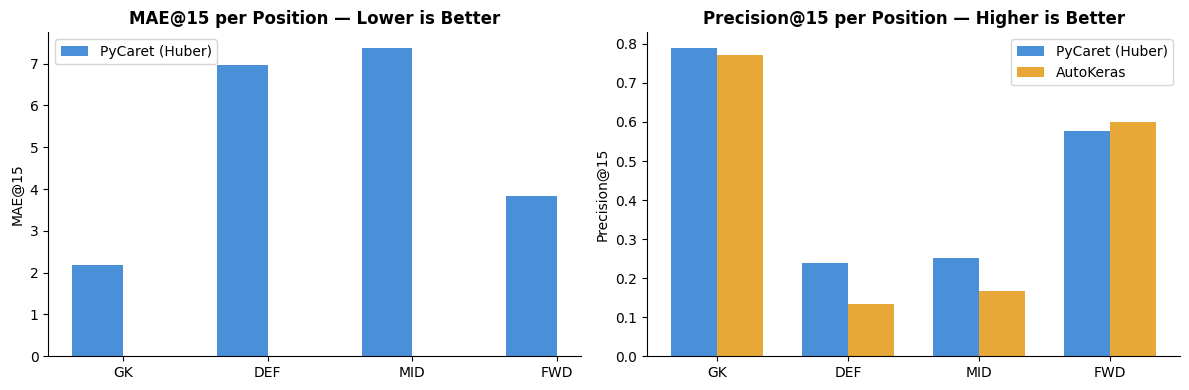

Saved.


In [12]:
import matplotlib.pyplot as plt
import numpy as np

positions = ['GK', 'DEF', 'MID', 'FWD']
pc_maek  = [2.1869, 6.9577, 7.3792, 3.8221]
ak_maek  = [2.1869, 6.9577, 8.4010, 3.8221]  # use only MID since others are garbage
pc_preck = [0.790,  0.238,  0.252,  0.576]
ak_preck = [0.771,  0.133,  0.167,  0.600]
pc_mae   = [1.8021, 1.7790, 1.5680, 1.6869]
ak_mae   = [2.0276, 1.8806, 2.0559, 2.0556]

# Print clean table
print(f'{"Position":<10} {"PC MAE@15":>10} {"PC P@15":>10} {"PC MAE":>10}')
print('-' * 45)
for pos, pm, pp, m in zip(positions, pc_maek, pc_preck, pc_mae):
    print(f'{pos:<10} {pm:>10.4f} {pp:>10.3f} {m:>10.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(positions))
w = 0.35

axes[0].bar(x - w/2, pc_maek, w, label='PyCaret (Huber)', color='#4a90d9', edgecolor='none')
axes[0].set_xticks(x); axes[0].set_xticklabels(positions)
axes[0].set_ylabel('MAE@15'); axes[0].set_title('MAE@15 per Position — Lower is Better', fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(x - w/2, pc_preck, w, label='PyCaret (Huber)', color='#4a90d9', edgecolor='none')
axes[1].bar(x + w/2, ak_preck, w, label='AutoKeras', color='#e8a838', edgecolor='none')
axes[1].set_xticks(x); axes[1].set_xticklabels(positions)
axes[1].set_ylabel('Precision@15'); axes[1].set_title('Precision@15 per Position — Higher is Better', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb3_position_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 13. Generate Per-GW Predictions (Winner Model per Position)

In [ ]:
import pickle
import tensorflow as tf
import autokeras as ak
import numpy as np
import pandas as pd
import json

with open(f'{DATA_DIR}/winners.json') as f:
    winners = json.load(f)

all_preds = []

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    d = pos_data[pos]
    winner = winners[pos]

    if winner == 'PyCaret':
        pc_preds = pd.read_csv(f'{DATA_DIR}/preds_{pos}.csv')
        pred_values = pc_preds['pred'].values
        y_true = pc_preds['y_true'].values
        meta = pc_preds[['name','team','position','element','season','GW']]
    else:
        ak_model = tf.keras.models.load_model(
            f'{MODEL_DIR}/autokeras_{pos}.keras',
            custom_objects=ak.CUSTOM_OBJECTS
        )
        pred_values = np.clip(ak_model.predict(d['X_test_imp']).flatten(), 0, None)
        y_true = d['y_test']
        meta = d['test_meta'].reset_index(drop=True)

    out = meta.copy().reset_index(drop=True)
    out['predicted_pts_mid'] = np.round(pred_values, 2)
    out['actual_pts']        = y_true
    out['model_used']        = winner
    all_preds.append(out)
    print(f'{pos} ({winner}): {len(out)} predictions')

final_preds = pd.concat(all_preds, ignore_index=True)
final_preds = final_preds.sort_values(['element', 'GW']).reset_index(drop=True)
final_preds.to_csv(f'{DATA_DIR}/predictions_pergw.csv', index=False)
print(f'\nFull predictions saved: {final_preds.shape}')
print(final_preds.head(5))

GK (PyCaret): 317 predictions
DEF (PyCaret): 1891 predictions
MID (PyCaret): 2424 predictions
FWD (PyCaret): 634 predictions

Full predictions saved: (5266, 9)
                name     team position  element  season  GW  \
0  David Raya Martín  Arsenal       GK        1    2526  15   
1  David Raya Martín  Arsenal       GK        1    2526  16   
2  David Raya Martín  Arsenal       GK        1    2526  17   
3  David Raya Martín  Arsenal       GK        1    2526  18   
4  David Raya Martín  Arsenal       GK        1    2526  19   

   predicted_pts_mid  actual_pts model_used  
0               2.66         2.0    PyCaret  
1               2.61         7.0    PyCaret  
2               2.65         2.0    PyCaret  
3               2.62         2.0    PyCaret  
4               2.61         1.0    PyCaret  


## 14. Final Results Summary

In [ ]:
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

with open(f'{DATA_DIR}/pycaret_results.json') as f:
    pc_res = json.load(f)
with open(f'{DATA_DIR}/autokeras_results.json') as f:
    ak_res = json.load(f)
with open(f'{DATA_DIR}/winners.json') as f:
    winners = json.load(f)

print('='*65)
print('NB3 — POSITION-SPECIFIC MODEL RESULTS')
print('='*65)
print(f'{"Pos":<6} {"Winner":<12} {"MAE":>8} {"R²":>8} {"Naive":>8} {"Impr":>8}')
print('-'*55)
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    w = winners[pos]
    mae = pc_res[pos]['mae'] if w == 'PyCaret' else ak_res[pos]['mae']
    r2  = pc_res[pos]['r2']  if w == 'PyCaret' else ak_res[pos]['r2']
    naive = pc_res[pos]['naive_mae']
    impr = ((naive - mae) / naive) * 100
    print(f'{pos:<6} {w:<12} {mae:>8.4f} {r2:>8.4f} {naive:>8.4f} {impr:>7.1f}%')

full = pd.read_csv(f'{DATA_DIR}/predictions_pergw.csv')
overall_mae = mean_absolute_error(full['actual_pts'], full['predicted_pts_mid'])
overall_r2  = r2_score(full['actual_pts'], full['predicted_pts_mid'])
print(f'\nOverall NB3 MAE: {overall_mae:.4f} | R²: {overall_r2:.4f}')
print()
print('=== Comparison vs NB2 (global model) ===')
print(f'NB2 Huber MAE: 0.8644 | R²: 0.2126')
print(f'NB3 Overall:   {overall_mae:.4f} | R²: {overall_r2:.4f}')
nb3_wins = overall_mae < 0.8644
print(f'NB3 wins on MAE: {nb3_wins}')

NB3 — POSITION-SPECIFIC MODEL RESULTS
Pos    Winner            MAE       R²    Naive     Impr
-------------------------------------------------------
GK     PyCaret        1.8021   0.0556   2.0721    13.0%
DEF    PyCaret        1.7790  -0.0117   2.0872    14.8%
MID    PyCaret        1.5680   0.1130   1.9546    19.8%
FWD    PyCaret        1.6869   0.0513   2.1496    21.5%

Overall NB3 MAE: 1.6721 | R²: 0.0590

=== Comparison vs NB2 (global model) ===
NB2 Huber MAE: 0.8644 | R²: 0.2126
NB3 Overall:   1.6721 | R²: 0.0590
NB3 wins on MAE: False


## 15. Generate Latest-GW Player Predictions (for Dashboard)

In [13]:
import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor

df_full = pd.read_csv(f'{BASE}/data/processed/featured_training_set.csv')
df_full = df_full.sort_values(['element', 'season', 'GW'])
latest  = df_full.groupby('element').last().reset_index()

META_COLS = ['name','team','position','element','season','GW','total_points']
FEATURE_COLS = [c for c in df_full.columns if c not in META_COLS]

all_latest = []

for pos in ['GK', 'DEF', 'MID', 'FWD']:
    d = pos_data[pos]

    # Retrain Huber directly — saves properly with pickle
    huber = HuberRegressor(epsilon=1.35, max_iter=200)
    huber.fit(d['X_train'], d['y_train'], sample_weight=d['w_train'])

    lat_pos = latest[latest['position'] == pos].copy()
    X_lat = lat_pos[FEATURE_COLS].values.astype(np.float32)

    with open(f'{MODEL_DIR}/imputer_{pos}.pkl', 'rb') as f:
        imputer = pickle.load(f)
    with open(f'{MODEL_DIR}/scaler_{pos}.pkl', 'rb') as f:
        scaler = pickle.load(f)

    X_scaled = scaler.transform(imputer.transform(X_lat))
    preds = np.clip(huber.predict(X_scaled), 0, None)

    out = lat_pos[['name','team','position','element','value']].copy().reset_index(drop=True)
    out['pos']           = pos
    out['predicted_pts'] = np.round(preds, 2)
    all_latest.append(out)
    print(f'{pos}: top 3 → {out.nlargest(3, "predicted_pts")[["name","predicted_pts"]].values}')

dashboard_preds = pd.concat(all_latest, ignore_index=True)
dashboard_preds.to_csv(f'{DATA_DIR}/predictions.csv', index=False)
print(f'\nSaved: {dashboard_preds.shape}')
print(dashboard_preds.sort_values('predicted_pts', ascending=False).head(15)[
    ['name','team','pos','predicted_pts','value']])

GK: top 3 → [['David Raya Martín' 5.27]
 ['Gianluigi Donnarumma' 4.98]
 ['Jordan Pickford' 4.95]]
DEF: top 3 → [['Gabriel dos Santos Magalhães' 7.09]
 ['Virgil van Dijk' 6.63]
 ['Jurriën Timber' 6.23]]
MID: top 3 → [['Mohamed Salah' 9.47]
 ['Bruno Borges Fernandes' 7.92]
 ['Cole Palmer' 7.71]]
FWD: top 3 → [['Erling Haaland' 7.84]
 ['Hugo Ekitiké' 6.79]
 ['João Pedro Junqueira de Jesus' 6.44]]

Saved: (820, 7)
                                 name       team  pos  predicted_pts  value
526                     Mohamed Salah  Liverpool  MID           9.47   14.0
559            Bruno Borges Fernandes    Man Utd  MID           7.92   10.0
768                    Erling Haaland   Man City  FWD           7.84   14.7
459                       Cole Palmer    Chelsea  MID           7.71   10.6
360                       Bukayo Saka    Arsenal  MID           7.13    9.8
94       Gabriel dos Santos Magalhães    Arsenal  DEF           7.09    7.1
392                   Antoine Semenyo   Man City  MID 